In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Modeling
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import ruptures as rpt
from sklearn.preprocessing import StandardScaler

In [3]:
# Given Data: Credit Owned, Personal Expenditure, Saving Rate
credit_owned = pd.read_csv('../datasets/CREDIT OWNED.csv')
personal_expenditure = pd.read_csv('../datasets/PERSONAL EXPENDITURE.csv')
saving_rate = pd.read_csv('../datasets/SAVING RATE.csv')
disposable_personal_income = pd.read_csv('../datasets/DSPIC96.csv')
avg_hourly_earnings = pd.read_csv('../datasets/CES0500000003.csv')
unemployment_rate = pd.read_csv('../datasets/UNRATE.csv')
federal_funds = pd.read_csv('../datasets/FEDFUNDS.csv')
food_cpi = pd.read_csv('../datasets/CPIUFDSL.csv')
cpi = pd.read_csv('../datasets/CPIAUCSL.csv')
energy_cpi = pd.read_csv('../datasets/CUSR0000SACE.csv')
shelter_cpi = pd.read_csv('../datasets/CUSR0000SAH1.csv')
cc_delinquency_rate = pd.read_csv('../datasets/DRCCLACBS.csv')

In [4]:
print(credit_owned.sample(5))
print(personal_expenditure.sample(5))
print(saving_rate.sample(5))
print(disposable_personal_income.sample(5))
print(avg_hourly_earnings.sample(5))
print(unemployment_rate.sample(5))
print(federal_funds.sample(5))
print(food_cpi.sample(5))
print(cpi.sample(5))
print(energy_cpi.sample(5))
print(shelter_cpi.sample(5))
print(cc_delinquency_rate.sample(5))

    observation_date     TOTALSL
244       1963-05-01    71335.14
185       1958-06-01    47507.36
28        1945-05-01     5605.25
914       2019-03-01  4051968.06
347       1971-12-01   146930.18
    observation_date   PCEC96
0         2007-01-01  11181.0
222       2025-07-01  16547.5
166       2020-11-01  13970.3
108       2016-01-01  12798.7
216       2025-01-01  16316.5
    observation_date  PSAVERT
571       2006-08-01      2.5
788       2024-09-01      4.8
254       1980-03-01     10.3
652       2013-05-01      5.3
513       2001-10-01      2.9
    observation_date  DSPIC96
686       2016-03-01  14135.4
228       1978-01-01   4962.0
1         1959-02-01   2325.4
256       1980-05-01   5134.3
525       2002-10-01  10661.8
    observation_date  CES0500000003
227       2025-02-01          35.94
120       2016-03-01          25.45
48        2010-03-01          22.46
46        2010-01-01          22.40
122       2016-05-01          25.58
    observation_date  UNRATE
579       1996-04

In [5]:
credit_owned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  995 non-null    object 
 1   TOTALSL           995 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.7+ KB


In [6]:
all_indicators = [credit_owned, personal_expenditure, saving_rate, disposable_personal_income, avg_hourly_earnings, unemployment_rate, federal_funds, food_cpi, cpi, energy_cpi, shelter_cpi, cc_delinquency_rate]
master_df = credit_owned
for i in all_indicators[1:]:
    master_df = master_df.merge(i, on='observation_date', how='outer')
print(master_df.sample(5))

    observation_date     TOTALSL   PCEC96  PSAVERT  DSPIC96  CES0500000003  \
623       1994-12-01   997301.74      NaN      7.0   8060.2            NaN   
785       2008-06-01  2662409.52  11340.7      4.6  12376.6          21.52   
440       1979-09-01   339449.75      NaN      9.4   5159.3            NaN   
550       1988-11-01   729660.07      NaN      8.4   6971.9            NaN   
523       1986-08-01   638904.39      NaN      8.9   6469.4            NaN   

     UNRATE  FEDFUNDS  CPIUFDSL  CPIAUCSL  CUSR0000SACE  CUSR0000SAH1  \
623     5.5      5.45   146.800   150.100       100.500       162.500   
785     5.6      2.00   213.333   217.463       330.121       246.406   
440     5.9     11.43    80.900    74.400        77.700        71.100   
550     5.3      8.35   120.500   120.300        80.300       129.200   
523     6.9      6.17   110.100   109.600        69.300       116.300   

     DRCCLACBS  
623        NaN  
785        NaN  
440        NaN  
550        NaN  
523    

In [7]:
master_df = master_df.rename(columns={'observation_date': 'date', 'TOTALSL': 'credit_owned', 'PCEC96': 'personal_expenditure', 'PSAVERT': 'saving_rate', 'DSPIC96': 'disposable_personal_income',
                                     'CES0500000003': 'avg_hourly_earnings', 'UNRATE': 'unemployment_rate', 'FEDFUNDS': 'federal_funds', 'CPIUFDSL': 'food_cpi', 'CPIAUCSL': 'cpi', 'CUSR0000SACE': 'energy_cpi',
                                     'CUSR0000SAH1': 'shelter_cpi', 'DRCCLACBS': 'cc_delinquency_rate'})

In [8]:
print(master_df.columns)

Index(['date', 'credit_owned', 'personal_expenditure', 'saving_rate',
       'disposable_personal_income', 'avg_hourly_earnings',
       'unemployment_rate', 'federal_funds', 'food_cpi', 'cpi', 'energy_cpi',
       'shelter_cpi', 'cc_delinquency_rate'],
      dtype='object')


In [9]:
master_df['date'] = pd.to_datetime(master_df['date'], format='%Y-%m-%d')
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        997 non-null    datetime64[ns]
 1   credit_owned                995 non-null    float64       
 2   personal_expenditure        227 non-null    float64       
 3   saving_rate                 803 non-null    float64       
 4   disposable_personal_income  804 non-null    float64       
 5   avg_hourly_earnings         239 non-null    float64       
 6   unemployment_rate           936 non-null    float64       
 7   federal_funds               859 non-null    float64       
 8   food_cpi                    948 non-null    float64       
 9   cpi                         948 non-null    float64       
 10  energy_cpi                  828 non-null    float64       
 11  shelter_cpi                 876 non-null    float64       

In [10]:
# After 2008 Crisis
start_date = '2010-01-01' 
covid_start = '2020-03-01'
covid_end = '2023-07-01'

# Cut out all data before start_date
master_df = master_df[master_df['date'] >= pd.Timestamp(start_date)]

if 'date' in master_df.columns:
    master_df = master_df.set_index('date')

# Set era for each row
def era_group(date):
    """
    The function categorizes each date into pre-covid, covid/inflation shock, post-shock era
    """
    if date < pd.Timestamp(covid_start):
        return 'Pre-COVID'
    elif date < pd.Timestamp(covid_end):
        return 'COVID/Inflation Shock'
    else:
        return 'Post-Shock'
        
master_df['era'] = master_df.index.map(era_group)

# Color map for eras
ERA_COLORS = {
    'Pre-COVID': '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock': '#4CAF50'
}

print(master_df['era'].value_counts())

era
Pre-COVID                122
COVID/Inflation Shock     40
Post-Shock                31
Name: count, dtype: int64


In [11]:
#Plot with colored era
COVID_START = pd.Timestamp('2020-03-01')    # WHO pandemic declaration
INFLATION_PEAK = pd.Timestamp('2022-06-01') # CPI-U peak at 9.1% YoY
RATE_HIKE_START = pd.Timestamp('2022-03-01') # First Fed rate hike
def plot_with_era(series, title, ylabel, ax=None, show_trend=True):
    """Plot a time series with colored era shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
    
    # era shading
    ax.axvspan(master_df.index.min(), pd.Timestamp('2020-02-01'),
               alpha=0.08, color=ERA_COLORS['Pre-COVID'], label='Pre-COVID')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
               alpha=0.08, color=ERA_COLORS['COVID/Inflation Shock'], label='COVID/Inflation')
    ax.axvspan(pd.Timestamp('2023-07-01'), master_df.index.max(),
               alpha=0.08, color=ERA_COLORS['Post-Shock'], label='Post-Shock')
    
    # Key event lines
    ax.axvline(COVID_START, color='red', ls='--', lw=1, alpha=0.7)
    ax.axvline(INFLATION_PEAK, color='orange', ls='--', lw=1, alpha=0.7)
    ax.axvline(RATE_HIKE_START, color='purple', ls='--', lw=1, alpha=0.7)
    
    # Data
    data = series.dropna()
    ax.plot(data.index, data.values, color='#333333', lw=1.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    return ax

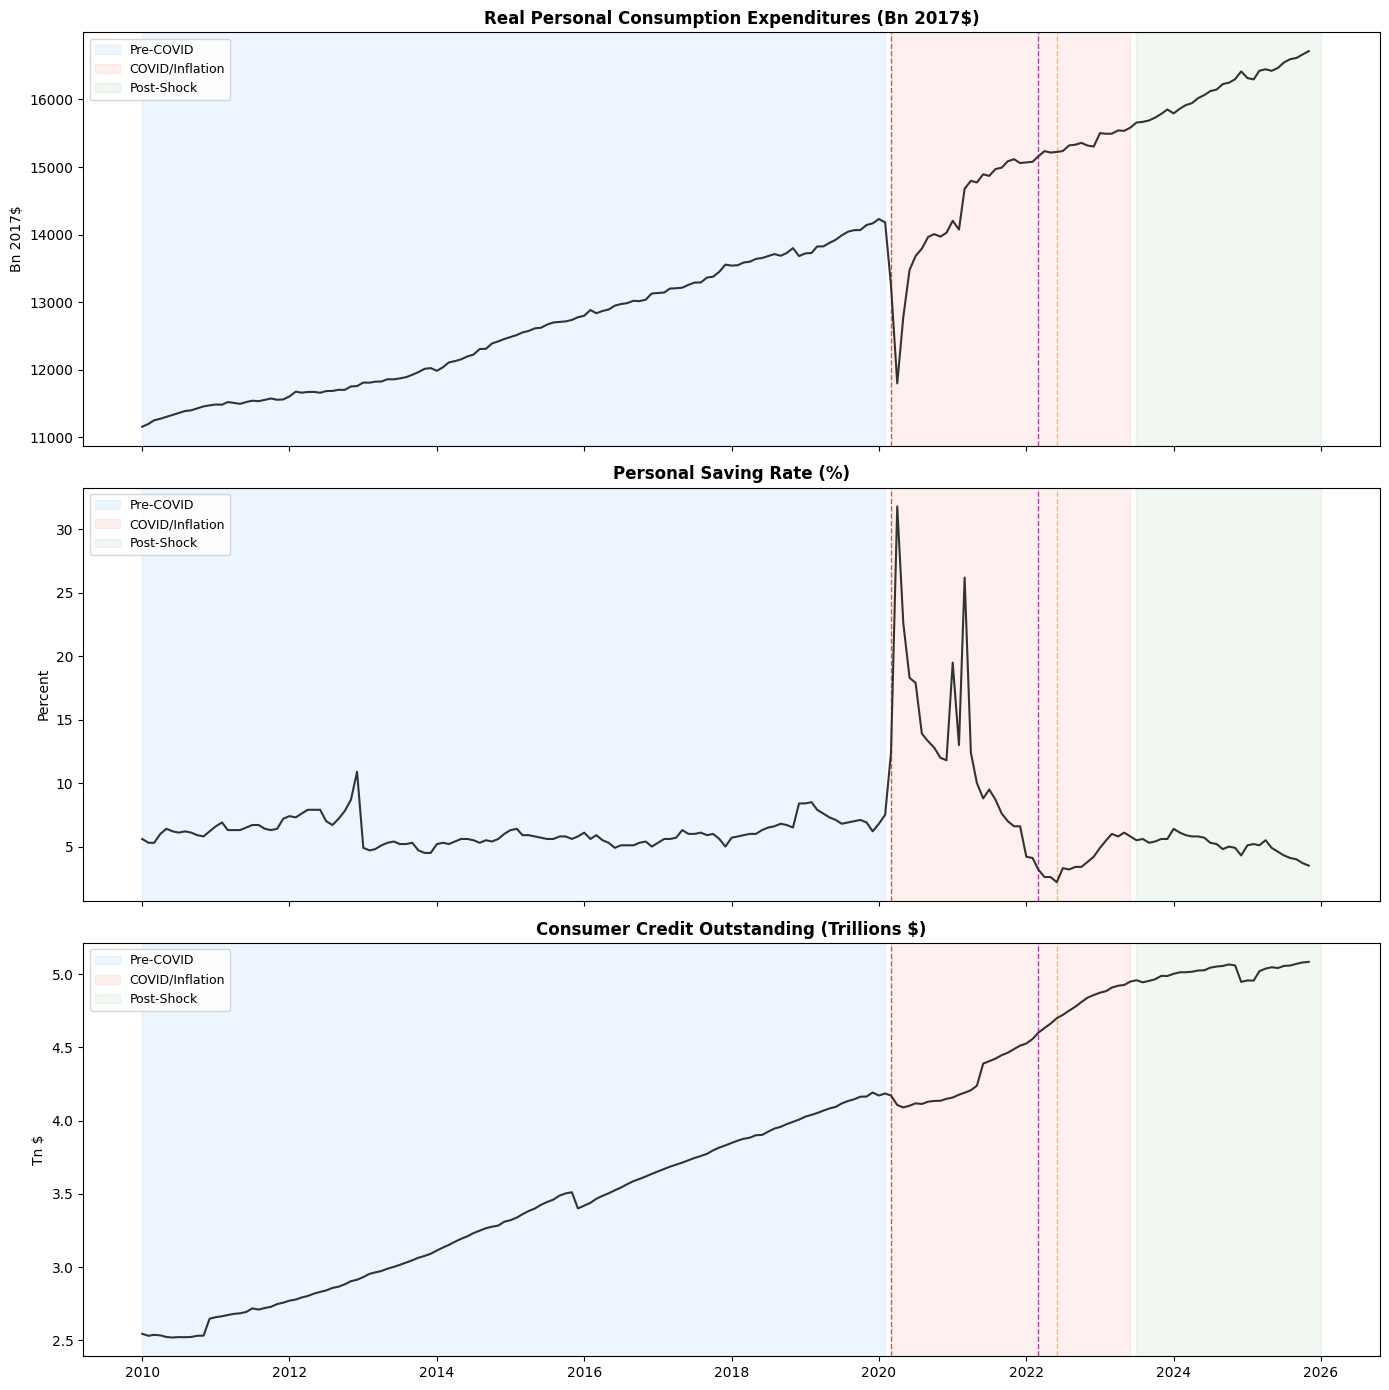

In [12]:
#Plot Credit Owned, Saving Rate, Personal Expenditure
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

plot_with_era(master_df['personal_expenditure'], 
    'Real Personal Consumption Expenditures (Bn 2017$)', 'Bn 2017$', axes[0])

plot_with_era(master_df['saving_rate'], 
    'Personal Saving Rate (%)', 'Percent', axes[1])

plot_with_era(master_df['credit_owned'] / 1e6, 
    'Consumer Credit Outstanding (Trillions $)', 'Tn $', axes[2])

plt.tight_layout()
plt.show()

In [13]:
# Calculate YoY and MoM change
master_df['pe_yoy'] = master_df['personal_expenditure'].pct_change(12) * 100
master_df['pe_mom'] = master_df['personal_expenditure'].pct_change(1) * 100
master_df['credit_yoy'] = master_df['credit_owned'].pct_change(12) * 100
master_df['credit_mom'] = master_df['credit_owned'].pct_change(1) * 100
master_df['hourly_wage_yoy'] = master_df['avg_hourly_earnings'].pct_change(12) * 100
master_df['income_yoy'] = master_df['disposable_personal_income'].pct_change(12) * 100
master_df['cpi_yoy'] = master_df['cpi'].pct_change(12) * 100
master_df['food_cpi_yoy'] = master_df['food_cpi'].pct_change(12) * 100
master_df['energy_cpi_yoy'] = master_df['energy_cpi'].pct_change(12) * 100
master_df['shelter_cpi_yoy'] = master_df['shelter_cpi'].pct_change(12) * 100

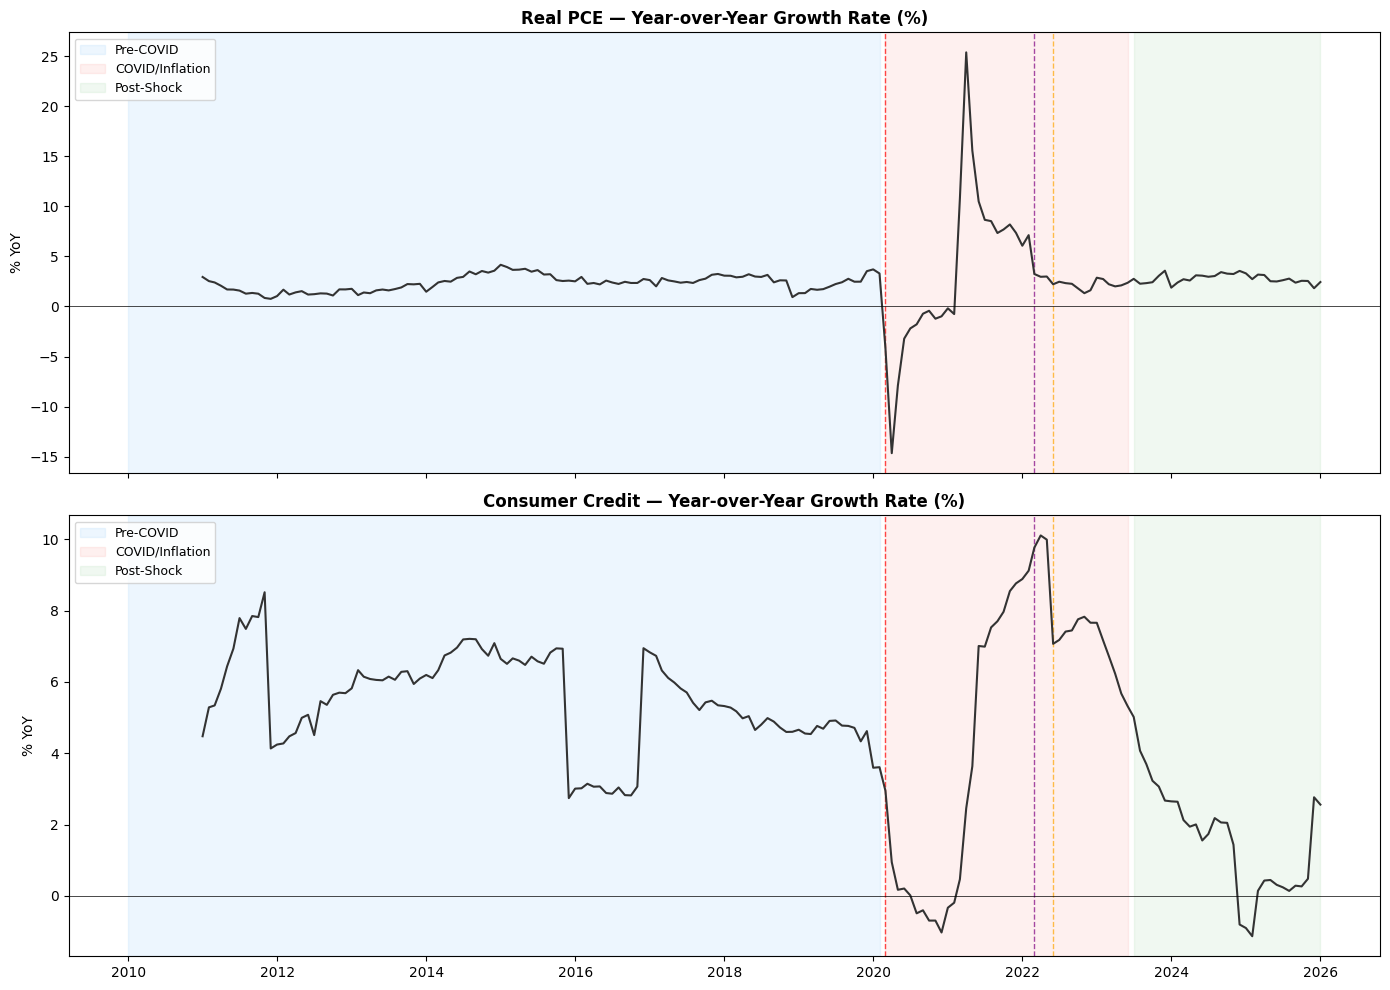

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

plot_with_era(master_df['pe_yoy'], 
    'Real PCE — Year-over-Year Growth Rate (%)', '% YoY', axes[0])
axes[0].axhline(0, color='black', lw=0.5)

plot_with_era(master_df['credit_yoy'], 
    'Consumer Credit — Year-over-Year Growth Rate (%)', '% YoY', axes[1])
axes[1].axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

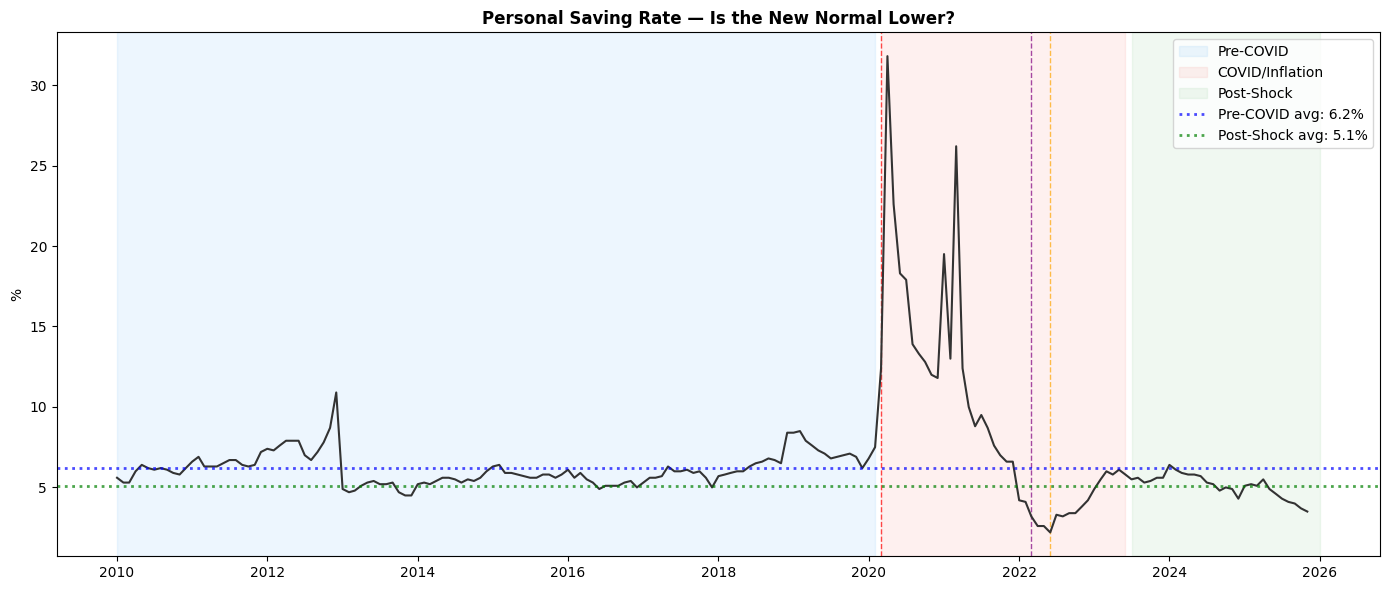

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
sr = master_df['saving_rate'].dropna()

# Pre-COVID average
pre_covid_mean = sr.loc[:COVID_START].mean()
post_shock_mean = sr.loc['2023-07-01':].mean()

plot_with_era(sr, 'Personal Saving Rate — Is the New Normal Lower?', '%', ax)

ax.axhline(pre_covid_mean, color='blue', ls=':', lw=2, alpha=0.7, 
           label=f'Pre-COVID avg: {pre_covid_mean:.1f}%')
ax.axhline(post_shock_mean, color='green', ls=':', lw=2, alpha=0.7, 
           label=f'Post-Shock avg: {post_shock_mean:.1f}%')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Model: Auto SARIMAX
Consumer spending, savings, and credit has seasonal patterns. It uses ARIMA at it's core so it utilizes trends and momentum. We are also using exogenous variables like cpi, fed funds, unemployment, wages which helps better forecast.

In [32]:
#Build the Model
START_DATE       = '2010-01-01'
COVID_START      = '2020-03-01'
COVID_END        = '2023-07-01'
TRAIN_END        = '2020-02-01'        # Last month of "normal" for training
SEASONAL_PERIOD  = 12                   # Monthly data

ERA_COLORS = {
    'Pre-COVID':             '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock':            '#4CAF50'
}

# The 3 core target series from the project brief
TARGETS = {
    'personal_expenditure': {
        'label': 'Real Personal Consumption Expenditures',
        'unit':  'Bn 2017$'
    },
    'saving_rate': {
        'label': 'Personal Saving Rate',
        'unit':  '%'
    },
    'credit_owned': {
        'label': 'Consumer Credit Outstanding',
        'unit':  'Mn $'
    }
}

# Exogenous features to feed into SARIMAX
EXOG_FEATURES = [
    'cpi', 'federal_funds', 'unemployment_rate',
    'disposable_personal_income', 'avg_hourly_earnings'
]

def build_counterfactual_model(df, target_col, exog_cols=None):
    train_mask = master_df.index <= pd.Timestamp(TRAIN_END)
    post_mask  = master_df.index > pd.Timestamp(TRAIN_END)

    y_train = master_df.loc[train_mask, target_col].dropna()
    y_post  = master_df.loc[post_mask, target_col].dropna()

    # Exogenous variables
    X_train, X_post = None, None
    if exog_cols:
        available_exog = [c for c in exog_cols if c in master_df.columns and c != target_col]
        if available_exog:
            scaler = StandardScaler()
            X_all = master_df[available_exog].interpolate(method='time').ffill().bfill()
            X_all[available_exog] = scaler.fit_transform(X_all[available_exog])

            X_train = X_all.loc[y_train.index]
            X_post  = X_all.loc[y_post.index]

    # Auto ARIMA
    print(f"Fitting auto_arima for: {target_col}")
    print(f"Training period: {y_train.index[0].strftime('%Y-%m')} → {y_train.index[-1].strftime('%Y-%m')}")
    print(f"Forecast period: {y_post.index[0].strftime('%Y-%m')} → {y_post.index[-1].strftime('%Y-%m')}")
    if X_train is not None:
        print(f"  Exogenous features: {available_exog}")

    auto_model = auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        stepwise=True,
        suppress_warnings=True,
        trace=False,
        error_action='ignore',
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        max_d=2, max_D=1,
        information_criterion='aic',
        n_fits=50
    )

    order = auto_model.order
    seasonal_order = auto_model.seasonal_order
    aic = auto_model.aic()

    print(f"Best order: ARIMA{order} x {seasonal_order}")
    print(f"AIC: {aic:.2f}")

    # Counterfactual forecast
    n_forecast = len(y_post)
    forecast, conf_int = auto_model.predict(
        n_periods=n_forecast,
        X=X_post,
        return_conf_int=True,
        alpha=0.05      # 95% CI
    )

    forecast_df = pd.DataFrame({
        'counterfactual':  forecast,
        'lower_ci':        conf_int[:, 0],
        'upper_ci':        conf_int[:, 1],
        'actual':          y_post.values
    }, index=y_post.index)

    # Gap = actual - counterfactual
    forecast_df['gap']     = forecast_df['actual'] - forecast_df['counterfactual']
    forecast_df['gap_pct'] = (forecast_df['gap'] / forecast_df['counterfactual']) * 100

    return {
        'model':          auto_model,
        'forecast_df':    forecast_df,
        'y_train':        y_train,
        'order':          order,
        'seasonal_order': seasonal_order,
        'aic':            aic,
        'exog_used':      available_exog if X_train is not None else []
    }

In [33]:
def run_all_models(master_df):
    """Build counterfactual models for all 3 core targets."""
    print(" AUTO-SARIMAX COUNTERFACTUAL MODELING")

    models = {}
    for col in TARGETS:
        models[col] = build_counterfactual_model(
            master_df, col, exog_cols=EXOG_FEATURES
        )
    return models

In [34]:
def gap_analysis(models, master_df):
    """Compute summary statistics for actual vs counterfactual gaps."""
    print(" GAP ANALYSIS — ACTUAL vs COUNTERFACTUAL")

    for col, meta in TARGETS.items():
        fdf = models[col]['forecast_df']

        # Split gap into COVID era and post-shock era
        covid_gap = fdf.loc[
            (fdf.index >= pd.Timestamp(COVID_START)) &
            (fdf.index < pd.Timestamp(COVID_END)), 'gap_pct'
        ]
        post_gap = fdf.loc[
            fdf.index >= pd.Timestamp(COVID_END), 'gap_pct'
        ]

        print(f"\n  {meta['label']}  ({meta['unit']})")
        print(f"Model: ARIMA{models[col]['order']} x {models[col]['seasonal_order']}")
        print(f"AIC: {models[col]['aic']:.2f}")
        print(f"Exogenous: {models[col]['exog_used']}")
        print(f"COVID/Inflation period mean gap: {covid_gap.mean():+.2f}%")
        print(f"Post-Shock period mean gap:      {post_gap.mean():+.2f}%")
        print(f"Latest gap ({fdf.index[-1].strftime('%Y-%m')}):        {fdf['gap_pct'].iloc[-1]:+.2f}%")

        # Is the gap converging?
        if len(post_gap) >= 6:
            recent = post_gap.iloc[-6:].mean()
            earlier = post_gap.iloc[:6].mean()
            if abs(recent) < abs(earlier) * 0.5:
                print(f"Trend: GAP CONVERGING (temporary disruption)")
            elif abs(recent) > abs(earlier):
                print(f"Trend: GAP WIDENING (structural shift)")
            else:
                print(f"Trend: GAP PERSISTENT (possible structural change)")

In [35]:
def plot_counterfactual(models, master_df, breaks_dict):
    """
    Create a 3-panel figure showing actual vs counterfactual
    for each core indicator, with structural breaks marked.
    """
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))
    fig.suptitle(
        'Has Inflation Permanently Changed Consumer Behaviour?\n'
        'Actual vs. Counterfactual (Pre-COVID SARIMAX Forecast)',
        fontsize=16, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        result = models[col]
        fdf = result['forecast_df']
        y_train = result['y_train']

        # Era shading
        ax.axvspan(master_df.index.min(), pd.Timestamp('2020-02-01'),
                   alpha=0.06, color=ERA_COLORS['Pre-COVID'])
        ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
                   alpha=0.06, color=ERA_COLORS['COVID/Inflation Shock'])
        ax.axvspan(pd.Timestamp('2023-07-01'), master_df.index.max(),
                   alpha=0.06, color=ERA_COLORS['Post-Shock'])

        # Training data
        ax.plot(y_train.index, y_train.values,
                color='#333', lw=1.5, label='Actual (training)')

        # Actual post-COVID
        ax.plot(fdf.index, fdf['actual'],
                color='#333', lw=2, label='Actual (observed)')

        # Counterfactual forecast
        ax.plot(fdf.index, fdf['counterfactual'],
                color='#E65100', lw=2, ls='--',
                label='Counterfactual (no-shock forecast)')

        # 95% confidence interval
        ax.fill_between(fdf.index,
                        fdf['lower_ci'], fdf['upper_ci'],
                        alpha=0.15, color='#E65100',
                        label='95% CI')

        # Shade the gap
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] > fdf['counterfactual'],
                        alpha=0.2, color='green', label='Above baseline')
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] < fdf['counterfactual'],
                        alpha=0.2, color='red', label='Below baseline')

        # Structural breaks
        if col in breaks_dict:
            for bdate in breaks_dict[col]:
                ax.axvline(bdate, color='magenta', ls=':', lw=2, alpha=0.8)
            if breaks_dict[col]:
                ax.axvline(breaks_dict[col][0], color='magenta', ls=':', lw=2,
                           alpha=0.8, label='Structural break')

        # COVID line
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']}  —  ARIMA{result['order']} x {result['seasonal_order']}",
                     fontsize=12, fontweight='bold')
        ax.set_ylabel(meta['unit'])
        ax.legend(loc='upper left', fontsize=8, ncol=2)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [36]:
def plot_gap_over_time(models):
    """Plot the percentage gap over time for each indicator."""
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(
        'Gap Analysis: How Far Is Reality From the No-Shock Baseline?',
        fontsize=15, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        fdf = models[col]['forecast_df']

        gap = fdf['gap_pct']
        colors = ['green' if g >= 0 else 'red' for g in gap]

        ax.bar(gap.index, gap.values, width=25, color=colors, alpha=0.6)
        ax.axhline(0, color='black', lw=1)

        # Rolling average trend
        rolling = gap.rolling(6).mean()
        ax.plot(rolling.index, rolling.values, color='#333', lw=2,
                label='6-month rolling avg')

        # Era dividers
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)
        ax.axvline(pd.Timestamp(COVID_END), color='green', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']} — % Deviation from Counterfactual", fontweight='bold')
        ax.set_ylabel('Gap (%)')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()


In [38]:
def print_model_summary(models):
    """Print concise diagnostics for each fitted model."""
    print(" MODEL DIAGNOSTICS SUMMARY")

    summary_rows = []
    for col, meta in TARGETS.items():
        m = models[col]
        summary_rows.append({
            'Indicator':       meta['label'],
            'Order':           f"ARIMA{m['order']}",
            'Seasonal':        f"{m['seasonal_order']}",
            'AIC':             round(m['aic'], 2),
            'Exog Features':   len(m['exog_used']),
            'Train Obs':       len(m['y_train']),
            'Forecast Obs':    len(m['forecast_df'])
        })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    return summary_df

In [39]:
def plot_residual_diagnostics(models):
    """Plot residuals for each model to check assumptions."""
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')

    for idx, (col, meta) in enumerate(TARGETS.items()):
        resid = models[col]['model'].resid()

        # Residual time series
        axes[idx, 0].plot(resid, color='#333', lw=0.8)
        axes[idx, 0].axhline(0, color='red', ls='--', lw=1)
        axes[idx, 0].set_title(f'{meta["label"]} — Residuals', fontsize=10)
        axes[idx, 0].set_ylabel('Residual')

        # Histogram
        axes[idx, 1].hist(resid, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
        axes[idx, 1].set_title(f'{meta["label"]} — Distribution', fontsize=10)
        axes[idx, 1].axvline(0, color='red', ls='--')

    plt.tight_layout()
    plt.show()

In [40]:
print('Fit the Model')
models = run_all_models(master_df)

Fit the Model
 AUTO-SARIMAX COUNTERFACTUAL MODELING
Fitting auto_arima for: personal_expenditure
Training period: 2010-01 → 2020-02
Forecast period: 2020-03 → 2025-11
  Exogenous features: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income', 'avg_hourly_earnings']
Best order: ARIMA(0, 0, 0) x (0, 0, 0, 12)
AIC: 1337.56
Fitting auto_arima for: saving_rate
Training period: 2010-01 → 2020-02
Forecast period: 2020-03 → 2025-11
  Exogenous features: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income', 'avg_hourly_earnings']
Best order: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 24.76
Fitting auto_arima for: credit_owned
Training period: 2010-01 → 2020-02
Forecast period: 2020-03 → 2025-11
  Exogenous features: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income', 'avg_hourly_earnings']
Best order: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 3335.09


In [41]:
print("Find the difference between actual and counterfactual")
gap_analysis(models, master_df)

Find the difference between actual and counterfactual
 GAP ANALYSIS — ACTUAL vs COUNTERFACTUAL

  Real Personal Consumption Expenditures  (Bn 2017$)
Model: ARIMA(0, 0, 0) x (0, 0, 0, 12)
AIC: 1337.56
Exogenous: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income', 'avg_hourly_earnings']
COVID/Inflation period mean gap: -1.81%
Post-Shock period mean gap:      -0.48%
Latest gap (2025-11):        -0.44%
Trend: GAP WIDENING (structural shift)

  Personal Saving Rate  (%)
Model: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 24.76
Exogenous: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income', 'avg_hourly_earnings']
COVID/Inflation period mean gap: +96.26%
Post-Shock period mean gap:      -220.65%
Latest gap (2025-11):        -147.51%
Trend: GAP PERSISTENT (possible structural change)

  Consumer Credit Outstanding  (Mn $)
Model: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 3335.09
Exogenous: ['cpi', 'federal_funds', 'unemployment_rate', 'disposable_personal_income'

In [42]:
print("Model diagnostics")
summary = print_model_summary(models)

Model diagnostics
 MODEL DIAGNOSTICS SUMMARY
                             Indicator          Order      Seasonal     AIC  Exog Features  Train Obs  Forecast Obs
Real Personal Consumption Expenditures ARIMA(0, 0, 0) (0, 0, 0, 12) 1337.56              5        122            69
                  Personal Saving Rate ARIMA(1, 0, 0) (0, 0, 0, 12)   24.76              5        122            69
           Consumer Credit Outstanding ARIMA(1, 0, 0) (0, 0, 0, 12) 3335.09              5        122            69


Visualization


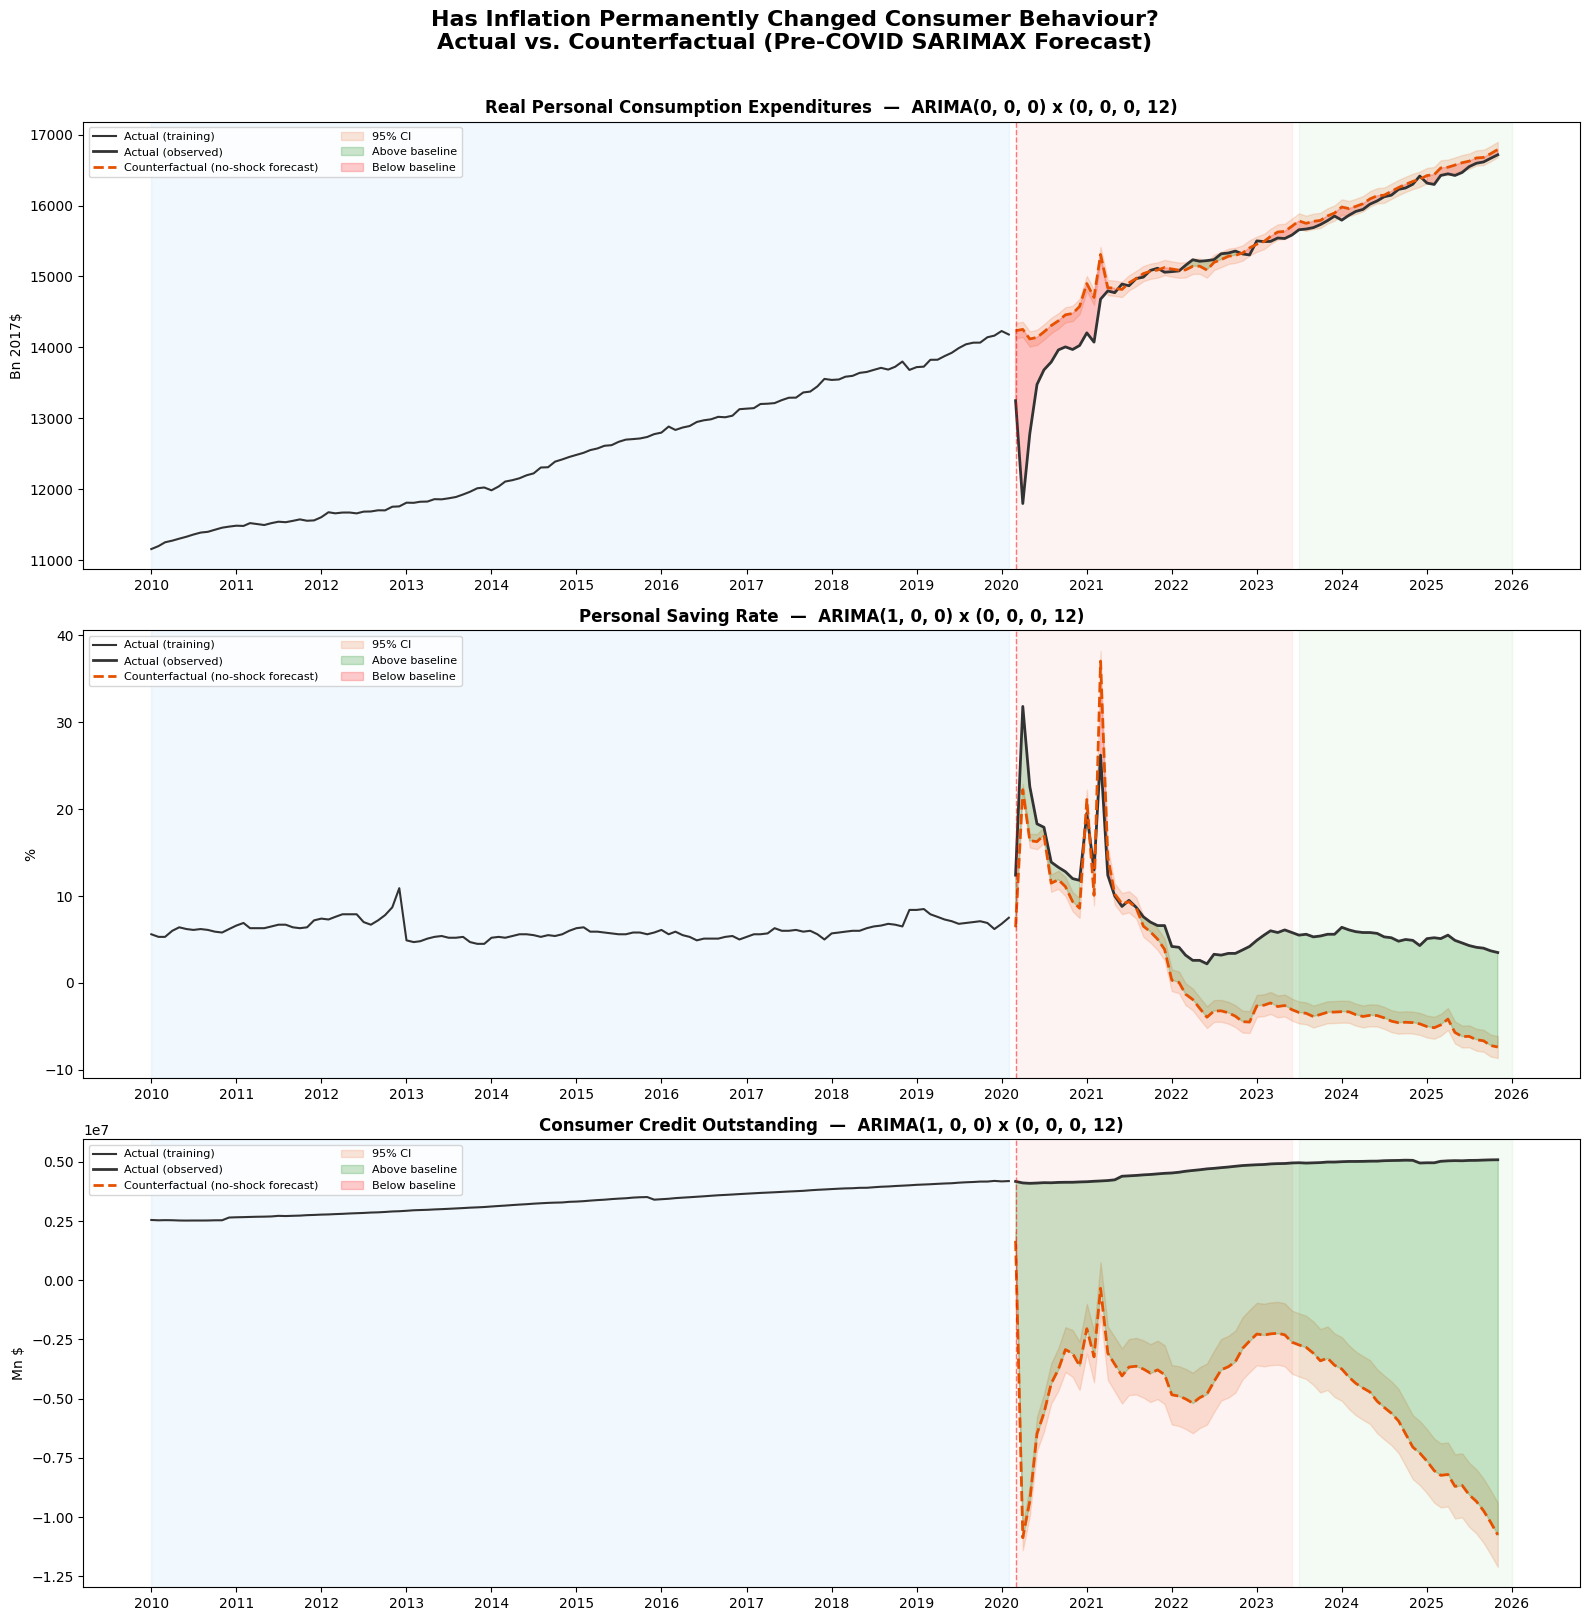

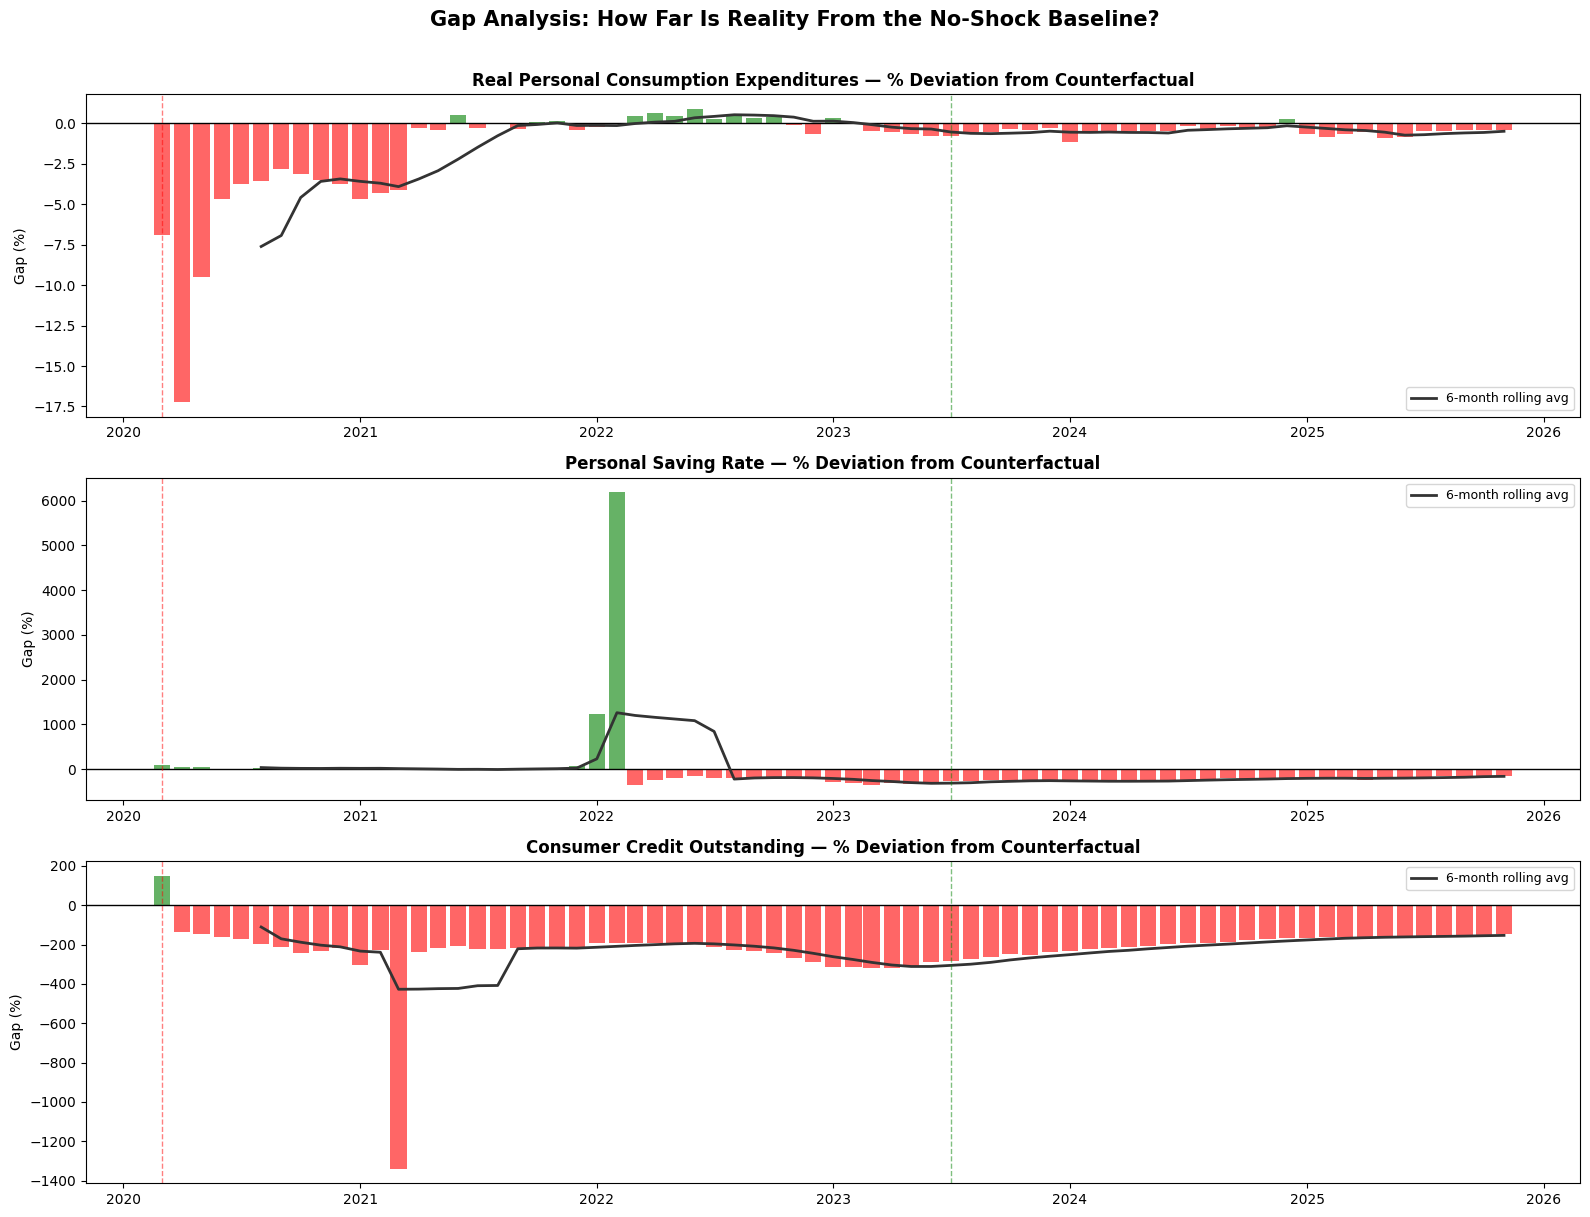

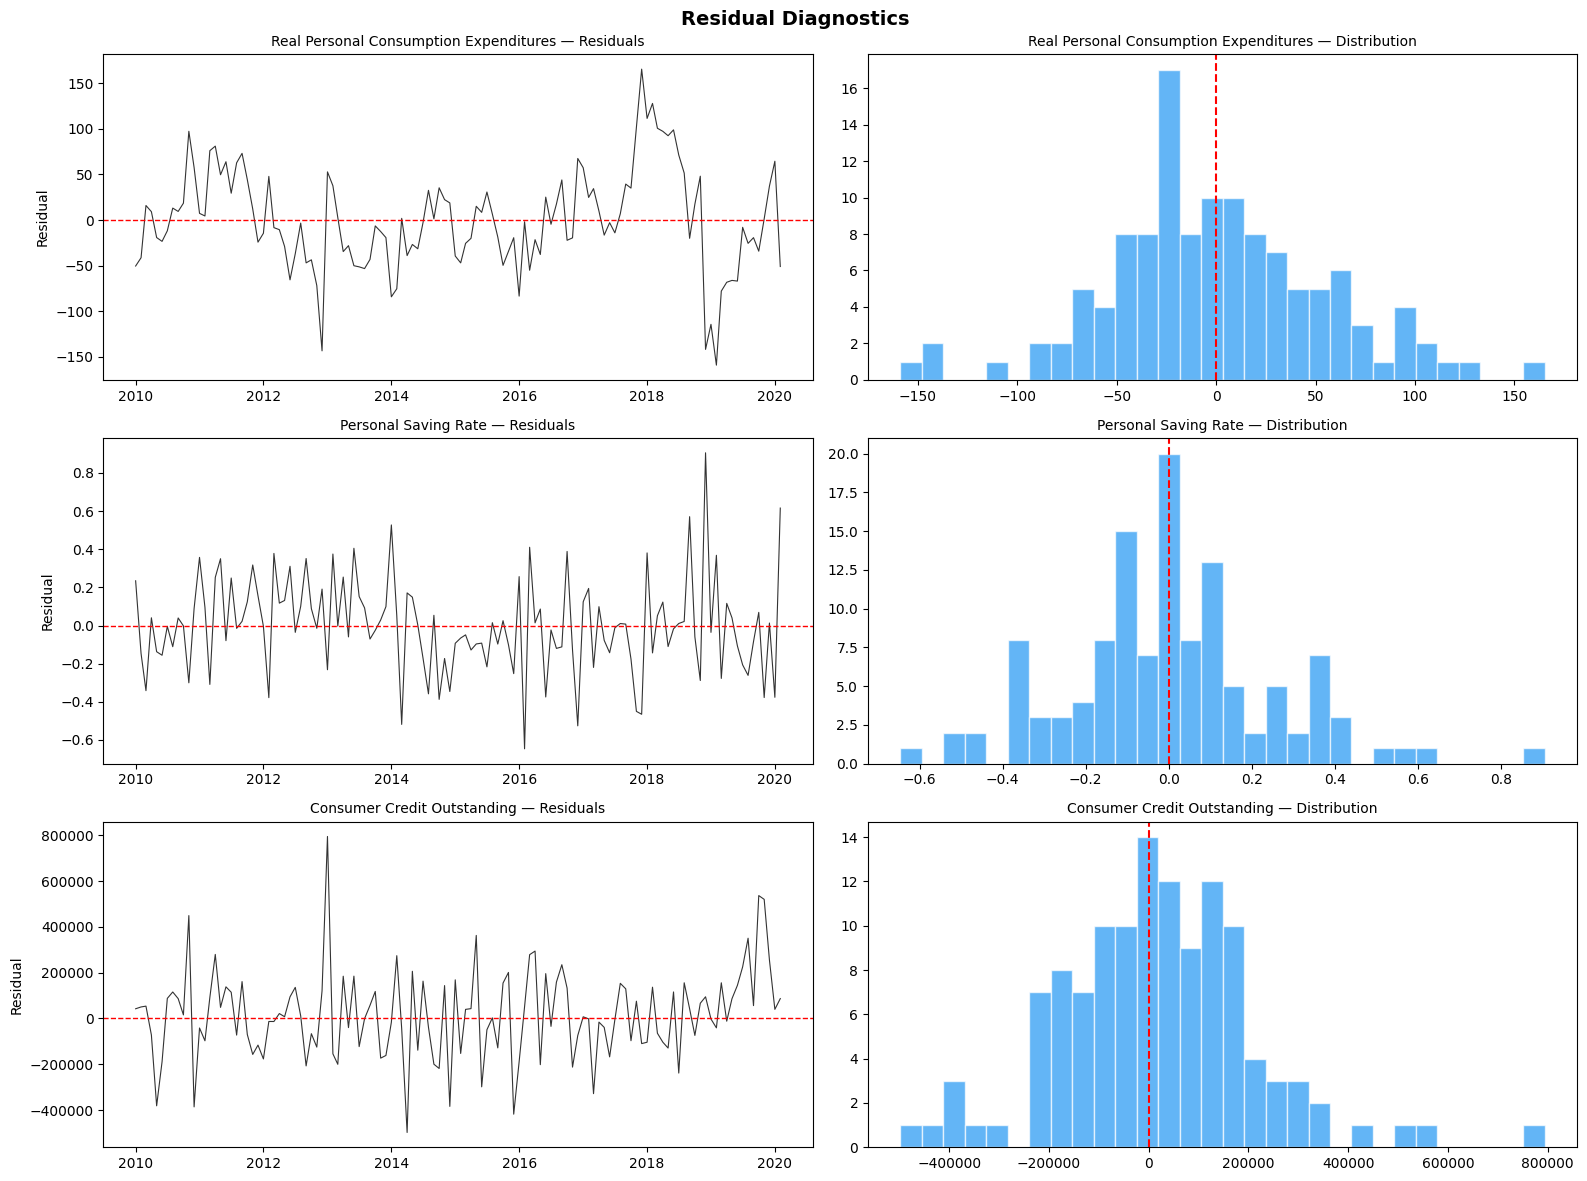

In [43]:
print("Visualization")
plot_counterfactual(models, master_df, breaks_dict={})
plot_gap_over_time(models)
plot_residual_diagnostics(models)